In [884]:
import requests
from datetime import datetime, UTC
from zoneinfo import ZoneInfo
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import geopandas as gpd
from shapely.geometry import Polygon, shape
from shapely.plotting import plot_polygon
from shapely import minimum_bounding_radius
import textwrap
from collections import Counter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings('ignore')

In [268]:
gdf = gpd.read_file('./cb_2018_us_county_20m/cb_2018_us_county_20m.shp')
gdf["STATEFP"] = gdf["STATEFP"].astype(str).str.zfill(2)

calnev_counties = gdf[(gdf["STATEFP"] == "06") | (gdf["STATEFP"] == "32")]

In [1222]:
"""
Algorithm condenses long lists of counties if they exceed a 
certain amount of characters to make space for the box (NHK style).

These regions are chosen arbitrarily by me but I'm going 
by what's generally used by locals/on the internet,
basing mainly off definitions in Wikipedia

Regions defined for Nevada would probably rarely be used, 
except for Western Nevada because most NV earthquakes occur there.
The rest of NV regions have large counties, and don't usually
have very large earthquakes that would require condensing the list.

There is a Humboldt County in both states. These would most likely
never get an EEW at the same time. The NV one is not defined in
a region for the reasons above.

Some blank strings are added so the threshold for condensing
a region doesn't get triggered at 1 or 2 counties in regions with few.
Threshold is (# of counties) - 3
"""

regions = {
    # ---- Northern California ----
    # Del Norte, Humboldt, Lake, Mendocino
    # "North Coast": ['015', '023', '033', '045'],
    "North Coast": ['Del Norte', 'Humboldt', 'Lake', 'Mendocino','',''],

    # Butte, Lassen, Modoc, Plumas, Shasta, Siskiyou, Tehama, Trinity
    # "The Cascades": ['007','035','049','063','089','103','105'],
    "The Cascades": ['Butte', 'Lassen', 'Modoc', 'Plumas', 'Shasta', 'Siskiyou', 'Tehama', 'Trinity'],

    # Plumas, Sierra, Nevada, Placer, Yuba, El Dorado, Amador, Alpine, Calaveras, Tuolumne, Mariposa, Mono, Madera, Tulare, Inyo
    # "Sierra Nevada": ['063', '091','057','061','115','017','005','003','009','109','043','051','039','107','027'],
    "Sierra Nevada": [
        'Plumas', 'Sierra', 'Nevada', 'Placer', 'Yuba', 'El Dorado', 'Amador', 
        'Alpine', 'Calaveras', 'Tuolumne', 'Mariposa', 'Mono', 'Madera', 'Tulare', 'Inyo'
        ],

    # Butte, Colusa, Glenn, Placer, Sacramento, Shasta, Sutter, Tehama, Yolo, Yuba
    # "Sacramento Valley": ['007','011','021','061','067','089','101','103','113','115'],
    "Sacramento Valley": [
        'Butte', 'Colusa', 'Glenn', 'Placer', 'Sacramento', 
        'Shasta', 'Sutter', 'Tehama', 'Yolo', 'Yuba'
        ],

    # San Joaquin, Kings, Stanislaus, Merced, Fresno, Madera, Tulare, Kern
    # "San Joaquin Valley": ['077','031','099','047','019','039','107','029'],
    "San Joaquin Valley": ['San Joaquin', 'Kings', 'Stanislaus', 'Merced', 'Fresno', 'Madera', 'Tulare', 'Kern'],

    # Alameda, Contra Costa, Marin, Napa, San Mateo, Santa Clara, Solano, Sonoma, San Francisco, Santa Cruz
    # "Bay Area": ['001','013','041','055','081','085','095','097','075','087'],
    "Bay Area": [
        'Alameda', 'Contra Costa', 'Marin', 'Napa', 'San Mateo', 
        'Santa Clara', 'Solano', 'Sonoma', 'San Francisco', 'Santa Cruz'
        ],

    # ---- Southern California ----
    # Santa Barbara, San Luis Obispo, Monterey, San Benito, Santa Cruz
    # "Central Coast": ['083','079','053','069','087'],
    "Central Coast": ['Santa Barbara', 'San Luis Obispo', 'Monterey', 'San Benito', 'Santa Cruz'],

    # Ventura, Los Angeles, Orange, Riverside, San Bernardino
    # "Greater LA Metro": ['111','037','059','065','071'],
    "Greater LA Metro": ['Ventura', 'Los Angeles', 'Orange', 'Riverside', 'San Bernardino', '', ''],

    #Inyo, San Bernardino, Riverside, Imperial
    # "Southeastern CA": ['027','071','065','025'],
    "Southeastern CA": ['Inyo', 'San Bernardino','Riverside', 'Imperial', '', ''],


    # ---- Nevada ----
    # Washoe, Carson City, Douglas, Storey, Lyon
    # "Western NV": ['031','510','005','029','019'],
    "Western NV": ['Washoe', 'Carson City', 'Douglas', 'Storey', 'Lyon'],
}

In [1319]:
def mmi_style(mmi,to_shindo=False):
    if mmi == 0: mmi = 1
    if mmi > 10: mmi = 10
    
    box_colors = ['white','lightblue','cyan','blue','green','yellow','orange','darkorange','red','darkred']
    txt_colors = ['k',    'k',    'k',       'w',   'w',    'k',      'k',     'k',        'w',  'y']
    weights =    [400,     400,    400,       400,   400,    400,      400,     600,       700,   800]
    MMI_ticks =  ['I',    'II',   'III',     'IV',  'V',    'VI',     'VII',   'VIII',     'IX',  'X']
    shindo =     ['0',     '1',    '2',       '3',   '4',   '5-',     '5+',    '6-',       '6+',  '7']
    descriptions = [
        'Not felt',
        'Weak',
        'Very light',
        'Light',
        'Moderate',
        'Strong',
        'Very strong',
        'Severe',
        'Violent',
        'Extreme'
    ]

    box_color = box_colors[mmi-1]
    txt_color = txt_colors[mmi-1]
    fnt_weight = weights[mmi-1]
    numeral = MMI_ticks[mmi-1]
    if to_shindo: numeral = shindo[mmi-1]
    description = descriptions[mmi-1]    

    return box_color, txt_color, fnt_weight, numeral, description

In [3]:
lims = [-127.376, -112.412, 31.166, 42.656]

In [1381]:
url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
query = {
    "format": "geojson",
    "starttime": '2020-01-01',
    "minmagnitude": '5.5',
    "minlongitude": lims[0],
    "maxlongitude": lims[1],
    "minlatitude": lims[2],
    "maxlatitude": lims[3],
    
}
r = requests.get(url, params=query)

if r.status_code == 200:
    data = r.json()
else:
    data = None
    print("error")

# pprint(data['features'])
print(len(data['features']))

17


In [1374]:
event = data['features'][7]
ev_name = event['properties']['title']
ev_time = event['properties']['time']
ev_utc = datetime.fromtimestamp(ev_time / 1000, UTC)
ev_local = ev_utc.astimezone(ZoneInfo("America/Los_Angeles"))
time_str = ev_local.strftime("%b %d, %Y %H:%M")
print(ev_name)
print(time_str)
event_detail_url = event['properties']['detail']
r2 = requests.get(event_detail_url)
ss_detail = r2.json()

try:
    eew_url = ss_detail['properties']['products']['shake-alert'][-1]['contents']['summary.json']['url']
    r3 = requests.get(eew_url)
    eew_data = r3.json()
    print('EEW report loaded')
except:
    print("Event has no ShakeAlert product.")

M 6.4 - 15km WSW of Ferndale, CA
Dec 20, 2022 02:34
EEW report loaded


In [1375]:
try:
    alert = eew_data['alerts'][-1]['features']
except:
    alert = eew_data['final_alert']['features']
# pprint(alert)

for feature in alert:
    if feature.get('id') == 'Epicenter' or feature.get('id') == 'finalEpicenter':
        epi_feat = feature
        continue
    
    featMMI = feature['properties'].get('name')
    if featMMI == 'MMI 4' or featMMI == "MMI 3.5":
    # if feature.get('id') == 'poly_2':
        MMI = feature['properties']['name']
        print(MMI)
        polygon_feat = feature

alert_poly = shape(polygon_feat)
epix, epiy = epi_feat['geometry']['coordinates']

MMI 4


In [1376]:
calnev_counties['warned'] = gdf.intersects(alert_poly)
colors = calnev_counties['warned'].map({True: 'yellow', False: 'white'})

warned_names = calnev_counties[calnev_counties['warned']==True]['NAME'].tolist()
warned_fips = calnev_counties[calnev_counties['warned']==True]['COUNTYFP'].tolist()

In [1377]:
regions_used = False

# about 400 characters should be able to fit in the text box
if len("".join(warned_names)) >= 50:
    warned_areas = list(warned_names)  # Use list, not numpy array
    condensed_counties = set()

    # Tally which regions are warned
    regions_tally = []
    for county in warned_names:
        for r in regions:
            if county in regions[r]:
                regions_tally.append(r)

    warns_per_region = Counter(regions_tally)

    # First pass: identify and add condensed regions
    for r in reversed(regions):
        if warns_per_region[r] >= len(regions[r]) - 3 or warns_per_region[r] > 7:
            print(f"Region {r} had {warns_per_region[r]} (max {len(regions[r])}) warnings and will be condensed")
            warned_areas.insert(0, r)  # Add region to front
            regions_used = True
            # Mark all warned counties in this region as condensed
            for county in regions[r]:
                if county in warned_names:
                    condensed_counties.add(county)

    # Second pass: remove condensed counties, add "Co." to remaining
    final_warned_areas = []
    for area in warned_areas:
        if area in regions.keys():  # It's a region name
            final_warned_areas.append(area)
        elif area not in condensed_counties:  # It's a county not in any condensed region
            final_warned_areas.append(f"{area} Co.")

    print(f'final list {final_warned_areas}')
else: 
    final_warned_areas = warned_names

Region North Coast had 4 (max 6) warnings and will be condensed
final list ['North Coast', 'Colusa Co.', 'Trinity Co.', 'Siskiyou Co.', 'Tehama Co.', 'Shasta Co.', 'Glenn Co.']


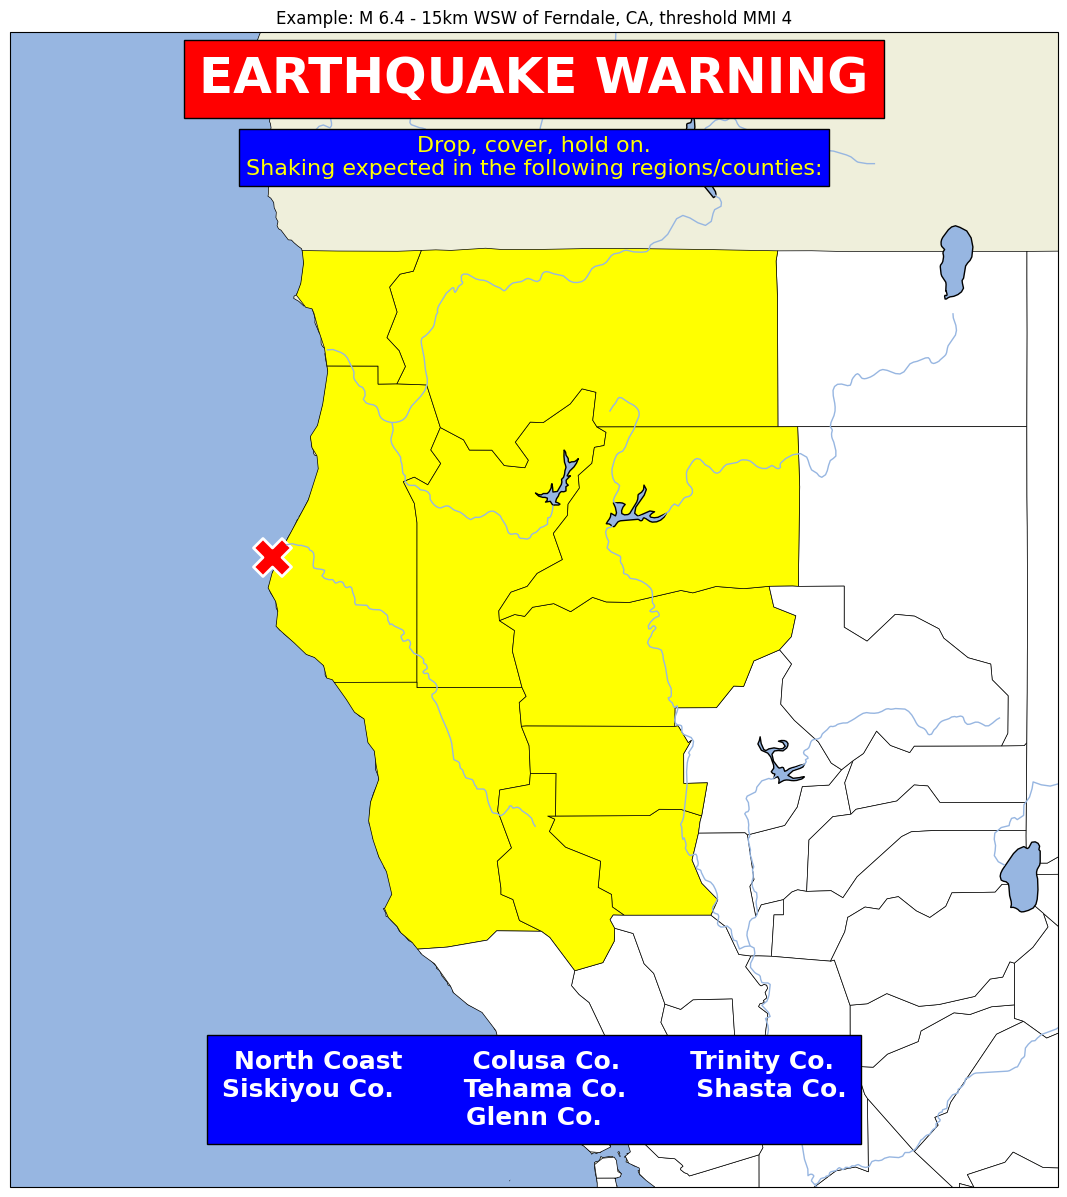

In [1382]:
fig, axi = plt.subplots(1,1,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})

calnev_counties.plot(ax=axi,color=colors,edgecolor='black',linewidth=0.5)

# poly_diameter = minimum_bounding_radius(alert_poly) * 2
# print(poly_diameter)
# poly_diameter = max(poly_diameter,1)
# map_lims = [epix - poly_diameter, epix + poly_diameter, epiy - poly_diameter/1.5, epiy + poly_diameter/1.5]
pad = 1.5
x1, y1, x2, y2 = calnev_counties[calnev_counties['warned']==True].total_bounds
map_lims = (x1 - pad, x2 + pad, y1 - pad/1.5, y2 + pad/1.5)

axi.set_extent(map_lims)

# axi.add_feature(cfeature.COASTLINE)
# axi.add_feature(cfeature.BORDERS, linestyle=':')
axi.add_feature(cfeature.LAND, edgecolor='black')
axi.add_feature(cfeature.LAKES, edgecolor='black')
axi.add_feature(cfeature.RIVERS)
# axi.add_feature(cfeature.STATES)
axi.add_feature(cfeature.OCEAN)


ew_style = dict(boxstyle='square', facecolor='red', edgecolor='black')
axi.text(0.5,0.98,'EARTHQUAKE WARNING',transform=axi.transAxes,fontsize=36,color='w',fontweight='bold',bbox=ew_style,va='top',ha='center')

psa_text = "Drop, cover, hold on.\nShaking expected in the following counties:"
if regions_used: psa_text = "Drop, cover, hold on.\nShaking expected in the following regions/counties:"
psa_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
axi.text(0.5,0.91,psa_text,transform=axi.transAxes,fontsize=16,color='yellow',bbox=psa_style,va='top',ha='center')

# warned_areas_list = ["12345678943546758697123456789123456789012345678901234567890987654321234567890-"]
warn_text = "\n".join(textwrap.wrap("        ".join(final_warned_areas), width=60))
clist_style = dict(boxstyle='square', facecolor='blue', edgecolor='k', pad=0.6)
axi.text(0.5,0.05,warn_text,transform=axi.transAxes,fontsize=18,color='w',fontweight='bold',bbox=clist_style,va='bottom',ha='center')

axi.scatter(epix,epiy,marker='X',c='r',ec='white',linewidths=2,s=750)
# plot_polygon(alert_poly)

axi.set_title(f"Example: {event['properties']['title']}, threshold {MMI}")
plt.show()

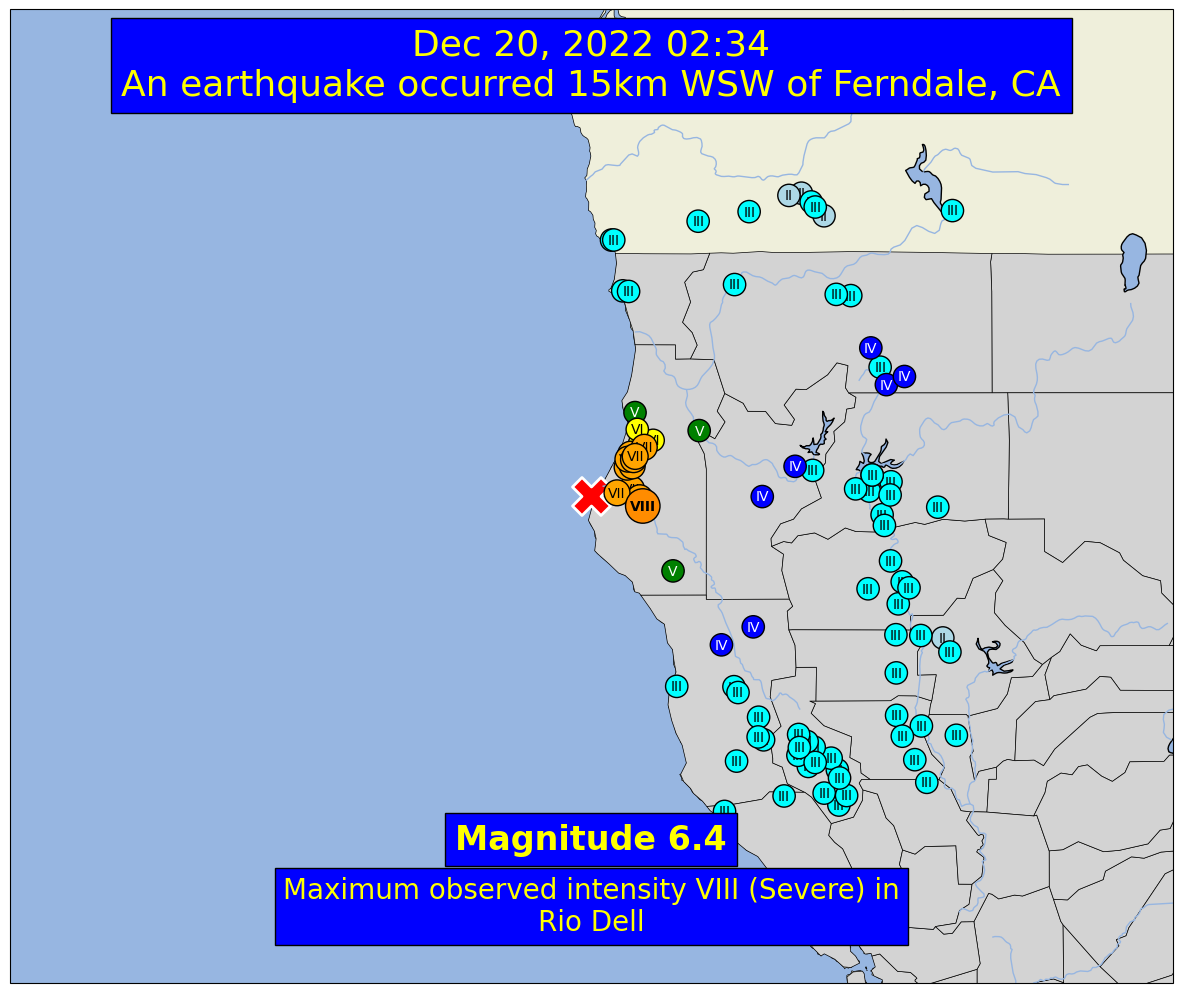

In [1380]:
city_mmi_url = ss_detail['properties']['products']['losspager'][0]['contents']['json/cities.json']['url']
r4 = requests.get(city_mmi_url)
city_mmis = r4.json()
city_mmis

source_data = ss_detail['properties']['products']['losspager'][0]['properties']
epix, epiy = float(source_data['longitude']), float(source_data['latitude'])
mag = float(source_data['magnitude'])
box_hl = mag/1.5 #degrees
x1, x2, y1, y2 = (epix - box_hl, epix + box_hl, epiy - box_hl/1.5, epiy + box_hl/1.5)

names = []
coord_pairs = []
mmis = []

for city in city_mmis['all_cities']:
    # if city['on_map']:
    names.append(city['name'])
    coord_pairs.append((city['lon'], city['lat']))
    mmis.append(city['mmi'])

mmis = np.round(np.array(mmis)).astype(int)
max_mmi = np.max(mmis)
_, _, _, maxnumeral, maxdesc = mmi_style(max_mmi)

max_ind = np.where(mmis == max_mmi)

# list of cities where max. intensity was seen
cities_max_mmi = np.array(names)[max_ind]

map_lims = (x1, x2, y1, y2)

fig, axi = plt.subplots(1,1,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})

axi.add_feature(cfeature.LAND, edgecolor='black')
axi.add_feature(cfeature.LAKES, edgecolor='black')
axi.add_feature(cfeature.RIVERS)
# axi.add_feature(cfeature.STATES)
axi.add_feature(cfeature.OCEAN)

report_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
report_txt = f'{time_str}\n{"\n".join(textwrap.wrap(f"An earthquake occurred {event['properties']['place']}",width=50))}'
axi.text(0.5,0.98,report_txt,transform=axi.transAxes,fontsize=26,color='yellow',bbox=psa_style,va='top',ha='center',zorder=15)

maxmmi_txt = f"Maximum observed intensity {maxnumeral} ({maxdesc}) in\n{"\n".join(textwrap.wrap(", ".join(cities_max_mmi[:10]), width=70))}"
axi.text(0.5,0.13,f"Magnitude {mag}",transform=axi.transAxes,fontsize=24,color='yellow',fontweight='bold',bbox=report_style,va='bottom',ha='center',zorder=15)
axi.text(0.5,0.11,maxmmi_txt,transform=axi.transAxes,fontsize=20,color='yellow',bbox=report_style,va='top',ha='center',zorder=15)

calnev_counties.plot(ax=axi,color='lightgray',edgecolor='black',linewidth=0.5)

for i, name in enumerate(names):
    x,y = coord_pairs[i][0],coord_pairs[i][1]
    # don't plot points out of bounds
    if (x < x1 or x > x2) or (y < y1 or y > y2):
        continue
    mmi = mmis[i]
    box_color, txt_color, fnt_weight, numeral, _ = mmi_style(mmi)
    mmi_bbox = dict(boxstyle='circle', facecolor=box_color, edgecolor='black')
    axi.text(
        x,y,numeral,
        bbox=mmi_bbox,
        c=txt_color,
        zorder=mmi+1,
        fontweight=fnt_weight,
        )
    
# in_map_counties = gpd.clip(calnev_counties,(x1,y1,x2,y2))

# for j, county in in_map_counties.iterrows():
#     centroid = county.geometry.representative_point()
#     axi.annotate(
#         text=county.NAME,
#         xy=(centroid.x,centroid.y),
#         c='gray',
#         fontsize=6
#     )

axi.set_extent(map_lims)

axi.scatter(epix,epiy,marker='X',c='r',ec='white',linewidths=2,s=750)

# axi.set_title(f"Example: {event['properties']['title']}")
plt.show()

In [1344]:
# warned_areas = np.copy(warned_names)
# regions_used = False

# regions_tally = []
# for county in warned_areas:
#     for r in regions:
#         if county in regions[r]:
#             regions_tally.append(r)
#             # print(county,r)

# warns_per_region = Counter(regions_tally)

# for r in reversed(regions):
#     if warns_per_region[r] >= len(regions[r]) - 3:
#         print(f"Region {r} had {warns_per_region[r]} warnings (max {len(regions[r])}) and will be condensed")
#         # add region to area names

#         warned_areas = np.concatenate(([r], warned_areas))
#         regions_used = True
#         print("Region added; pruning counties")
#         for county in warned_names:
#             print(f'testing {county} county')
#             if county in regions[r]:
#                 print(f'county {county} in region {r} {regions[r]}')
#                 #remove county names for region that was condensed
#                 warned_areas = warned_areas[warned_areas != county]
#             else:
#                 # else give county "Co." so it is understood it's a county
#                 warned_areas[np.where(warned_areas==county)] = f'{county} Co.'

# print(f'final list {warned_areas}')

In [1177]:
eew_url

'https://earthquake.usgs.gov/product/shake-alert/ew1774649600/ew/1774659399413/summary.json'

In [1345]:
event

{'type': 'Feature',
 'properties': {'mag': 6.6,
  'place': '164 km W of Ferndale, California',
  'time': 1481208585910,
  'updated': 1651601069554,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us20007z6r',
  'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us20007z6r&format=geojson',
  'felt': 2588,
  'cdi': 4.5,
  'mmi': 3.97,
  'alert': 'green',
  'status': 'reviewed',
  'tsunami': 1,
  'sig': 1120,
  'net': 'us',
  'code': '20007z6r',
  'ids': ',us20007z6r,at00ohvfux,pt16343051,nc72734605,iscgem609838893,',
  'sources': ',us,at,pt,nc,iscgem,',
  'types': ',dyfi,impact-link,impact-text,losspager,moment-tensor,nearby-cities,origin,phase-data,scitech-link,shakemap,',
  'nst': None,
  'dmin': 1.405,
  'rms': 1.11,
  'gap': 55,
  'magType': 'mww',
  'type': 'earthquake',
  'title': 'M 6.6 - 164 km W of Ferndale, California'},
 'geometry': {'type': 'Point', 'coordinates': [-126.1936, 40.4535, 8.45]},
 'id': 'us20007z6r'}